# Benchmark — Estimateurs de rendement espéré μ (Expected Returns)

**Question.** Quel estimateur de μ est le plus pertinent pour l'optimisation de portefeuille sur
le S&P 500, évalué **hors échantillon** selon : (1) sa **qualité prédictive**, (2) sa
**robustesse** (régime, fenêtre), (3) son **impact réel** sur la performance OOS des portefeuilles ?

**Protocole d'isolation de μ.** On **fige Σ = Ledoit-Wolf** (covariance régularisée, donc bien
conditionnée) et on ne fait varier QUE `mean_estimator` (`dataclasses.replace`), mêmes
fenêtres/coûts. Backtest walk-forward OOS corrigé (Sharpe net de rf, coûts symétriques, anti
look-ahead).


## 1. Données et configuration

In [1]:
import sys, time, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".."); sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import replace

import portfolio_lab as pl
from portfolio_lab.backtest import WalkForwardBacktestConfig, plot_backtest_nav

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

USE_SYNTHETIC = False
START, END = "2012-01-01", "2025-12-31"

In [2]:
# Univers CONFIGURABLE (S&P 500 complet, Top N, Random N, Sector Stratified)
constituents = pl.get_sp500_constituents()

SELECTOR = pl.StratifiedBySector(n_total=100, seed=42)   
# SELECTOR = pl.AllUniverse()        # S&P 500 complet
# SELECTOR = pl.TopN(50)             # N premiers (ALPHABÉTIQUE)
# SELECTOR = pl.RandomN(50, seed=42) # aléatoire reproductible

universe = SELECTOR.select(constituents)
if USE_SYNTHETIC:
    prices = pl.make_synthetic_prices(constituents.loc[universe], START, END)
else:
    prices = pl.clean_prices(pl.download_prices(universe, START, END))
returns = pl.compute_returns(prices, "simple")
print(f"Univers : {prices.shape[1]} actifs | {prices.shape[0]} obs "
      f"({prices.index[0].date()} -> {prices.index[-1].date()})")

[OK] 503 composants récupérés depuis Wikipédia.


Univers : 82 actifs | 3450 obs (2012-04-12 -> 2025-12-30)


In [3]:
BT_CFG = WalkForwardBacktestConfig(
    estimation_window=252, holding_period=21, transaction_cost_bps=10.0,
    long_only=True, frequency="daily", risk_free_annual=0.04,
)
PPY = pl.periods_per_year(BT_CFG.frequency)
WINDOW, STEP = BT_CFG.estimation_window, BT_CFG.holding_period

# Les 5 estimateurs de μ comparés (returns-only).
mean_estimators = {
    "SampleMean":   pl.SampleMean(),
    "RollingMean":  pl.RollingMean(window=63),
    "EWMAMean":     pl.EWMAMean(lam=0.94),
    "JamesStein":   pl.JamesSteinMean(),
    "PCAFactor":    pl.PCAFactorMean(n_factors=3),
}
# Σ FIGÉE = Ledoit-Wolf : on régularise la covariance pour ISOLER proprement l'effet de μ
# (l'empirique non régularisée serait bruitée quand la fenêtre approche N).
COV_FIXED = pl.LedoitWolfCovariance()
print("Estimateurs μ :", list(mean_estimators), "| Σ figée :", COV_FIXED.name)

Estimateurs μ : ['SampleMean', 'RollingMean', 'EWMAMean', 'JamesStein', 'PCAFactor'] | Σ figée : ledoit-wolf


## 2. Qualité predictive

Métriques : erreur (RMSE, MAE, WMAPE), corrélation niveau (**Pearson**) et **rang (IC = Spearman, la métrique clé)**, et **hit-rate** directionnel.

In [4]:
pred = pl.mean_eval_summary(returns, mean_estimators, window=WINDOW, step=STEP)
cols = ["rmse", "mae", "wmape", "pearson", "IC", "hit_rate"]
display(pred[cols].round({"rmse":6,"mae":6,"wmape":4,"pearson":4,"IC":4,"hit_rate":4}))
print("Rappel : un IC moyen de 0.02-0.05 est déjà 'bon'. Des IC proches de 0 (voire négatifs) "
      "confirment que μ est dominé par le bruit (H1).")

,rmse,mae,wmape,pearson,IC,hit_rate
SampleMean,0.0039,0.0030,1.0182,0.0089,0.0011,0.5461
RollingMean,0.0045,0.0034,1.1533,-0.0078,-0.0147,0.5135
EWMAMean,0.0050,0.0038,1.3049,-0.0060,-0.0094,0.5184
JamesStein,0.0038,0.0029,0.9842,-0.0090,-0.0441,0.5690
PCAFactor,0.0039,0.0029,0.9944,0.0031,0.0094,0.5653


Rappel : un IC moyen de 0.02-0.05 est déjà 'bon'. Des IC proches de 0 (voire négatifs) confirment que μ est dominé par le bruit (H1).


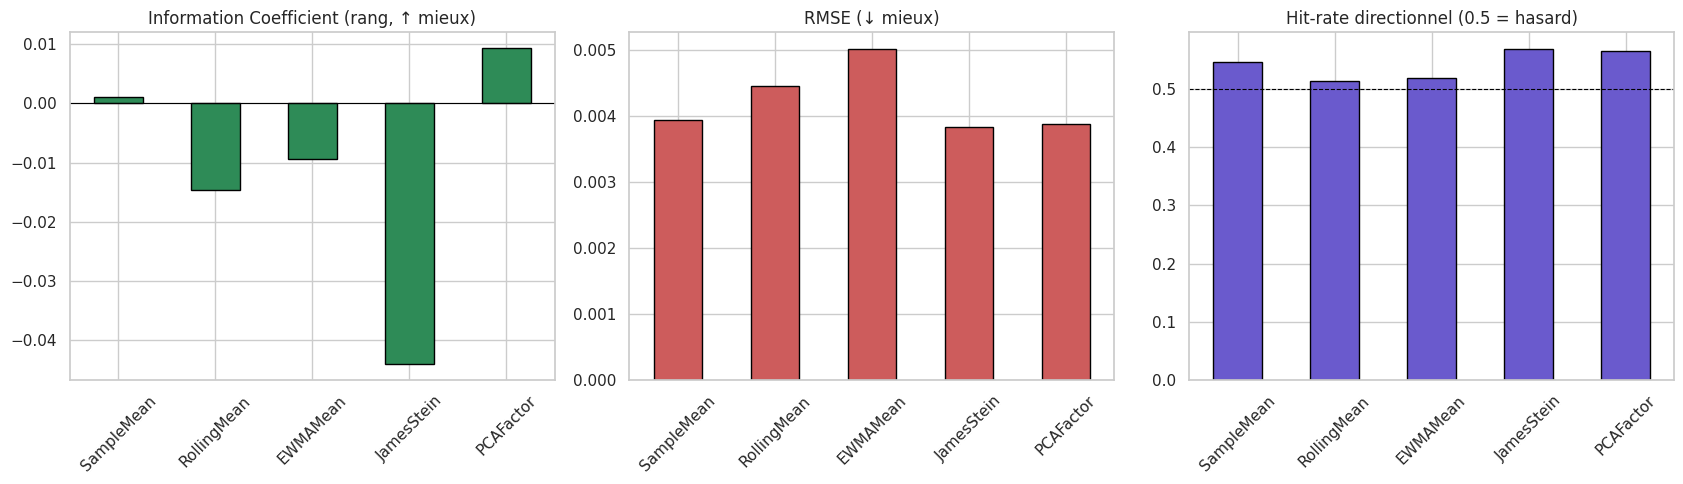

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
pred["IC"].plot(kind="bar", ax=axes[0], color="seagreen", edgecolor="black")
axes[0].axhline(0, color="black", lw=0.8); axes[0].set_title("Information Coefficient (rang, ↑ mieux)")
pred["rmse"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="black")
axes[1].set_title("RMSE (↓ mieux)")
pred["hit_rate"].plot(kind="bar", ax=axes[2], color="slateblue", edgecolor="black")
axes[2].axhline(0.5, color="black", lw=0.8, ls="--"); axes[2].set_title("Hit-rate directionnel (0.5 = hasard)")
for a in axes: a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 3. Stabilité 

**Sensibilité à la fenêtre** : IC moyen pour `window ∈ {126, 252, 300}`. Un bon estimateur est
**plat** (peu sensible au choix de fenêtre).

,SampleMean,RollingMean,EWMAMean,JamesStein,PCAFactor
window,,,,,
126,-0.0079,-0.0168,-0.0115,-0.0281,-0.0017
252,0.0011,-0.0147,-0.0094,-0.0441,0.0094
300,0.0092,-0.0086,-0.0170,-0.0443,-0.0129


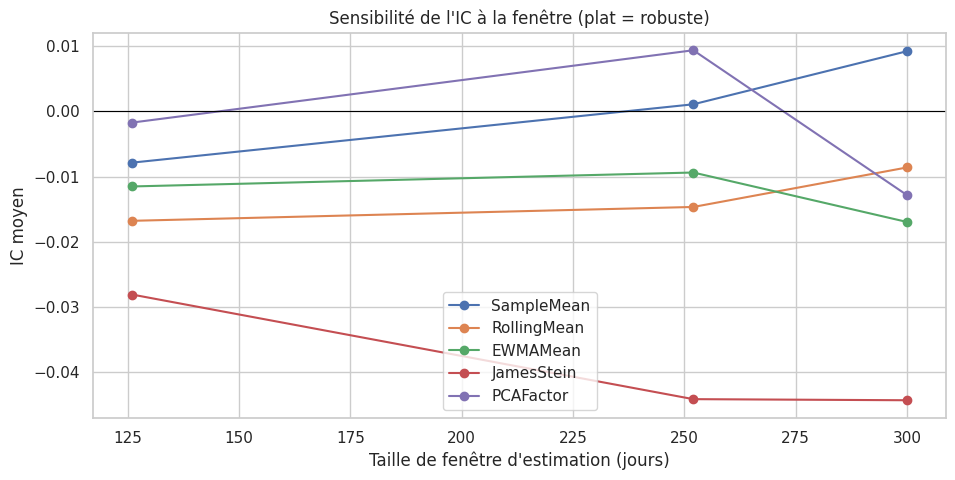

In [6]:
WINDOWS = [126, 252, 300]
sens = pd.DataFrame({name: pl.window_sensitivity(returns, est, WINDOWS, step=STEP)
                     for name, est in mean_estimators.items()})
display(sens.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
for name in sens.columns:
    ax.plot(sens.index, sens[name], marker="o", label=name)
ax.set_xlabel("Taille de fenêtre d'estimation (jours)"); ax.set_ylabel("IC moyen")
ax.axhline(0, color="black", lw=0.8); ax.set_title("Sensibilité de l'IC à la fenêtre (plat = robuste)")
ax.legend(); plt.show()

## 4. Impact **portefeuille** (isolateur de μ, Σ = Ledoit-Wolf)

### a. On varie l'estimateur de μ (max_utility) — avec les bornes qui IGNORENT μ
`Min-Var` et `Équipondéré 1/N` ne dépendent pas de μ 

In [7]:
base = pl.ExperimentConfig(
    universe=SELECTOR, frequency=BT_CFG.frequency, return_mode="simple",
    cov_estimator=COV_FIXED, objective="max_utility", optimizer=pl.CVXPYOptimizer(),
    long_only=True, w_max=0.10, risk_free_annual=0.04,
)
variants = {f"Max_utility / {n}": replace(base, mean_estimator=e) for n, e in mean_estimators.items()}
variants["[ref] Min-Var (ignore μ)"] = replace(base, objective="min_variance", mean_estimator=pl.SampleMean())
variants["[ref] Équipondéré 1/N"]    = replace(base, optimizer=pl.EqualWeightOptimizer(), mean_estimator=pl.SampleMean())

res = pl.run_oos_benchmark(prices, variants, backtest_config=BT_CFG)
cols_perf = ["CAGR (%)", "Vol annualized (%)", "Sharpe", "Max drawdown (%)",
             "Tracking error (%)", "Average turnover", "Fallback count"]
m = pl.metrics_table(res)
display(m[cols_perf].round(3))

,CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Tracking error (%),Average turnover,Fallback count
Max_utility / SampleMean,19.1120,20.8520,0.7250,-41.5140,13.5890,0.0250,0.0000
Max_utility / RollingMean,16.1100,19.7300,0.6140,-41.1820,12.6420,0.0500,0.0000
Max_utility / EWMAMean,15.0800,19.5340,0.5670,-38.8210,11.7330,0.0690,0.0000
Max_utility / JamesStein,9.2530,14.0460,0.3740,-34.3650,9.4380,0.0200,0.0000
Max_utility / PCAFactor,10.2910,22.6380,0.2780,-52.0630,14.5420,0.0260,0.0000
[ref] Min-Var (ignore μ),9.7890,13.2250,0.4380,-34.3650,9.0370,0.0130,0.0000
[ref] Équipondéré 1/N,15.6760,16.9070,0.6910,-38.6510,0.0000,0.0000,0.0000


In [8]:
display(pl.tail_metrics_table(res, periods_per_year_=PPY, rf_annual=0.04).round(3))
display(pl.weight_stability(res).round(4))

,Sortino,Calmar,VaR 5% (%),CVaR 5% (%),Skew,Kurtosis
Max_utility / SampleMean,0.6740,0.4600,1.9680,3.1300,-0.7730,8.3930
Max_utility / RollingMean,0.5730,0.3910,1.9000,2.9540,-0.6850,7.0440
Max_utility / EWMAMean,0.5360,0.3880,1.8410,2.8980,-0.7630,8.4970
Max_utility / JamesStein,0.3450,0.2690,1.2160,2.1080,-1.2040,21.0740
Max_utility / PCAFactor,0.2590,0.1980,2.1100,3.3900,-0.9530,11.4650
[ref] Min-Var (ignore μ),0.4050,0.2850,1.1090,1.9180,-1.3160,26.2460
[ref] Équipondéré 1/N,0.6530,0.4060,1.4900,2.4740,-0.6850,20.8550


,turnover moyen,Herfindahl moyen,N actifs effectifs
Max_utility / SampleMean,0.5232,0.0966,10.3478
Max_utility / RollingMean,1.0317,0.0980,10.2017
Max_utility / EWMAMean,1.4350,0.0983,10.1732
Max_utility / JamesStein,0.4064,0.0646,15.4890
Max_utility / PCAFactor,0.5468,0.0910,10.9834
[ref] Min-Var (ignore μ),0.2717,0.0610,16.3911
[ref] Équipondéré 1/N,0.0000,0.0122,82.0000


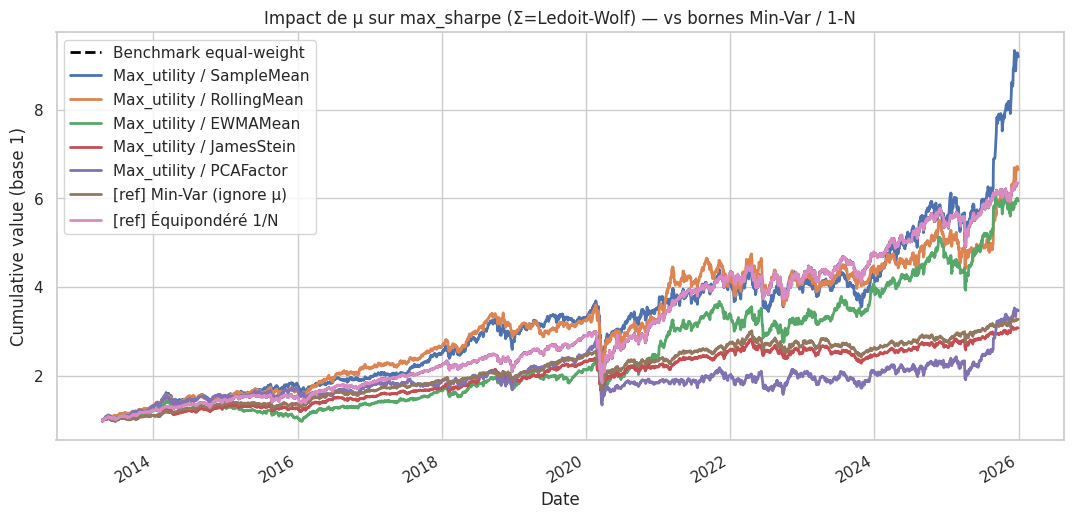

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_backtest_nav(res, ax=ax)
ax.set_title("Impact de μ sur max_sharpe (Σ=Ledoit-Wolf) — vs bornes Min-Var / 1-N")
plt.show()

### b. Comparaison des stratégies (meilleur μ vs constructions sans μ)
EW, Min-Var, Risk Parity, Max Diversification **ignorent μ** ; 

Mean-Variance et Max Sharpe en dépendent. On utilise le μ le mieux classé en IC pour les deux dernières.

In [10]:
best_mu_name = pred["IC"].idxmax()
best_mu = mean_estimators[best_mu_name]
print("Meilleur μ (IC) :", best_mu_name)
b = replace(base, mean_estimator=best_mu)
strategies = {
    "Équipondéré 1/N":       replace(b, optimizer=pl.EqualWeightOptimizer()),
    "Min variance":          replace(b, objective="min_variance"),
    "Risk parity":           replace(b, optimizer=pl.RiskParityOptimizer()),
    "Max diversification":   replace(b, optimizer=pl.MaxDiversificationOptimizer()),
    "Mean-Variance (utility)": replace(b, objective="max_utility"),
    "Max Sharpe":            replace(b, objective="max_sharpe"),
}
res_s = pl.run_oos_benchmark(prices, strategies, backtest_config=BT_CFG)
m_s = pl.metrics_table(res_s)
display(m_s[cols_perf].round(3))
display(pl.tail_metrics_table(res_s, periods_per_year_=PPY, rf_annual=0.04).round(3))

Meilleur μ (IC) : PCAFactor


,CAGR (%),Vol annualized (%),Sharpe,Max drawdown (%),Tracking error (%),Average turnover,Fallback count
Équipondéré 1/N,15.6760,16.9070,0.6910,-38.6510,0.0000,0.0000,0.0000
Min variance,9.7890,13.2250,0.4380,-34.3650,9.0370,0.0130,0.0000
Risk parity,14.1510,15.5550,0.6530,-37.2180,2.5350,0.0020,0.0000
Max diversification,13.9330,14.8000,0.6710,-36.0580,7.6940,0.0120,0.0000
Mean-Variance (utility),10.2910,22.6380,0.2780,-52.0630,14.5420,0.0260,0.0000
Max Sharpe,11.7430,20.1470,0.3840,-44.1250,12.4580,0.0270,0.0000


,Sortino,Calmar,VaR 5% (%),CVaR 5% (%),Skew,Kurtosis
Équipondéré 1/N,0.6530,0.4060,1.4900,2.4740,-0.6850,20.8550
Min variance,0.4050,0.2850,1.1090,1.9180,-1.3160,26.2460
Risk parity,0.6110,0.3800,1.3390,2.2810,-0.8660,23.2890
Max diversification,0.6190,0.3860,1.3150,2.1730,-1.3400,20.9830
Mean-Variance (utility),0.2590,0.1980,2.1100,3.3900,-0.9530,11.4650
Max Sharpe,0.3580,0.2660,1.8880,3.0060,-0.7980,12.1800


## 5. Exemple concret — allocation de 100 000 € 
On optimise un `max_sharpe` avec le meilleur μ uniquement sur le passé, on fige, on applique au
futur, et on compare au 1/N.

μ retenu : PCAFactor | Passé : 2448 obs | Futur : 1002 obs


,poids (%),montant
actif,,
DXCM,10.0000,10000.0000
MPWR,10.0000,10000.0000
CRM,10.0000,10000.0000
REGN,10.0000,10000.0000
AVGO,10.0000,10000.0000
DHI,10.0000,10000.0000
GPN,10.0000,10000.0000
BLK,9.8700,9872.1200
PAYX,5.7300,5725.4100


,valeur finale,P&L,rendement total (%),rendement annualisé (%),volatilité (%),Sharpe,max drawdown (%)
Stratégie,155773.5800,55773.5800,55.7700,11.8000,23.8900,0.3300,-26.6100
Équipondéré 1/N,147000.5900,47000.5900,47.0000,10.1800,15.9400,0.3900,-16.8000


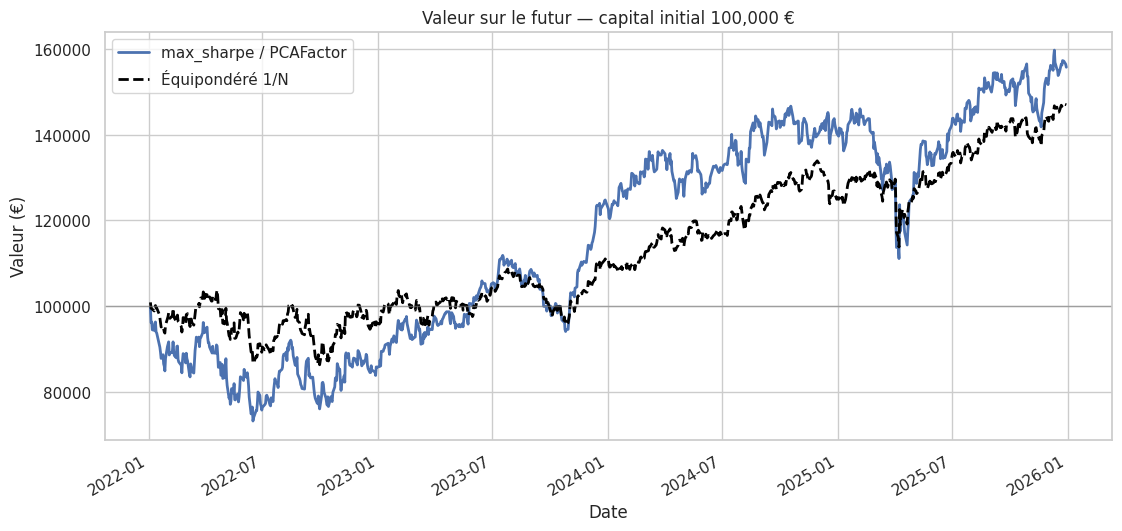

In [11]:
CAPITAL, SPLIT = 100_000.0, "2022-01-01"
best_cfg = replace(base, mean_estimator=best_mu)
ex = pl.train_test_split_evaluation(prices, best_cfg, split_date=SPLIT, capital=CAPITAL,
                                    frequency=BT_CFG.frequency, rf_annual=0.04)
print(f"μ retenu : {best_mu_name} | Passé : {ex['n_past']} obs | Futur : {ex['n_future']} obs")
display(ex["allocation"].head(12))
display(ex["comparison"].round(2))

fig, ax = plt.subplots(figsize=(13, 6))
ex["strategy_nav"].plot(ax=ax, lw=2, label=f"max_sharpe / {best_mu_name}")
ex["benchmark_nav"].plot(ax=ax, lw=2, ls="--", color="black", label="Équipondéré 1/N")
ax.axhline(CAPITAL, color="gray", lw=1, alpha=0.6)
ax.set_title(f"Valeur sur le futur — capital initial {CAPITAL:,.0f} €")
ax.set_ylabel("Valeur (€)"); ax.legend(); plt.show()

## 6. Matrice de décision & recommandations

In [12]:
# Agrège qualité prédictive, robustesse et impact portefeuille (sur max_sharpe).
mu_only = m.loc[[f"Max_utility / {n}" for n in mean_estimators]].copy()
mu_only.index = list(mean_estimators)
window_stab = sens.std(axis=0)   # variabilité de l'IC selon la fenêtre (bas = robuste)

decision = pd.DataFrame({
    "Qualité prédictive (IC ↑)":   pred["IC"].rank(ascending=False),
    "Erreur (RMSE ↓)":             pred["rmse"].rank(ascending=True),
    "Robustesse fenêtre (↓ std)":  window_stab.rank(ascending=True),
    "Sharpe portefeuille (↑)":     mu_only["Sharpe"].rank(ascending=False),
    "Stabilité poids (turnover ↓)": pl.weight_stability(res).loc[
        [f"Max_utility / {n}" for n in mean_estimators]].set_axis(list(mean_estimators))["turnover moyen"].rank(ascending=True),
})
decision["RANG MOYEN"] = decision.mean(axis=1)
display(decision.sort_values("RANG MOYEN").round(2))

print("\nMeilleur prédictif (IC)       :", pred["IC"].idxmax())
print("Meilleur Sharpe portefeuille  :", mu_only["Sharpe"].idxmax())
print("Le plus robuste (fenêtre)     :", window_stab.idxmin())
print("Compromis global (rang moyen) :", decision['RANG MOYEN'].idxmin())
print("\nRéférence Min-Var (ignore μ)  : Sharpe =",
      round(m.loc['[ref] Min-Var (ignore μ)','Sharpe'],3),
      "| à comparer au meilleur μ ci-dessus (H3).")

,Qualité prédictive (IC ↑),Erreur (RMSE ↓),Robustesse fenêtre (↓ std),Sharpe portefeuille (↑),Stabilité poids (turnover ↓),RANG MOYEN
SampleMean,2.0000,3.0000,3.0000,1.0000,2.0000,2.2000
JamesStein,5.0000,1.0000,4.0000,4.0000,1.0000,3.0000
RollingMean,4.0000,4.0000,2.0000,2.0000,4.0000,3.2000
PCAFactor,1.0000,2.0000,5.0000,5.0000,3.0000,3.2000
EWMAMean,3.0000,5.0000,1.0000,3.0000,5.0000,3.4000



Meilleur prédictif (IC)       : PCAFactor
Meilleur Sharpe portefeuille  : SampleMean
Le plus robuste (fenêtre)     : EWMAMean
Compromis global (rang moyen) : SampleMean

Référence Min-Var (ignore μ)  : Sharpe = 0.438 | à comparer au meilleur μ ci-dessus (H3).


##  Journalisation du run (`results/`)


In [13]:
from portfolio_lab.reporting import RunReport

rep = RunReport("return", results_dir="results")
rep.capture(
    prices=prices, selector=SELECTOR,
    requested_n=getattr(SELECTOR, "n_total", getattr(SELECTOR, "n", None)),
    period=(START, END), bt_cfg=BT_CFG, base_config=base, use_synthetic=USE_SYNTHETIC,
    mean_estimators=mean_estimators, cov_estimators={"Σ figée": COV_FIXED},
)
ns = globals()
rep.add_if(ns, "pred",     "Qualité prédictive de μ (IC, RMSE, hit-rate)")
rep.add_if(ns, "sens",     "Sensibilité de l'IC à la fenêtre")
rep.add_if(ns, "res",      "Impact portefeuille — on varie μ (max_sharpe)", columns=cols_perf)
rep.add_if(ns, "res_s",    "Comparaison des stratégies (meilleur μ)",       columns=cols_perf)
rep.add_if(ns, "decision", "Matrice de décision (rangs)")
print("Rapport écrit :", rep.save())   # rep.save(fmt="both") pour tenter un PDF (pandoc)


Rapport écrit : results/return__2026-06-21_111233.md
